In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from tqdm import tqdm

In [4]:
print(os. getcwd())

c:\Users\luisb\OneDrive\Documentos\uni\Maestrado\Year 1\Semester 2\Deep Learning\Project


In [8]:
# ──────────────────────────────────────────────
# 1.  Build the DataFrame
# ──────────────────────────────────────────────

WIKIART_DIR = os.path.join("./", "wikiart")

rows = []
for artist_name in tqdm(sorted(os.listdir(WIKIART_DIR))):
    artist_path = os.path.join(WIKIART_DIR, artist_name)
    for img_file in sorted(os.listdir(artist_path)):
        img_full = os.path.join(artist_path, img_file)
        # Build the relative path starting with ./wikiart
        img_rel = f"./wikiart/{artist_name}/{img_file}"
        img = Image.open(img_full).convert("RGB")
        img_np = np.array(img)
        h, w, c = img_np.shape
        rows.append({
            "image_path": img_rel,
            "artist": artist_name,
            "width": w,
            "height": h,
            "channels": c,
            "image_array": img_np})


df = pd.DataFrame(rows)


100%|██████████| 23/23 [02:22<00:00,  6.18s/it]


In [9]:
print(f"\n✅ DataFrame built: {len(df)} images, {df['artist'].nunique()} artists")
df.head(2)


✅ DataFrame built: 13340 images, 23 artists


,image_path,artist,width,height,channels,image_array
0,./wikiart/Albrecht_Durer/albrecht-durer_a-life...,Albrecht_Durer,512,512,3,"[[[163, 163, 163], [163, 163, 163], [163, 163,..."
1,./wikiart/Albrecht_Durer/albrecht-durer_a-nure...,Albrecht_Durer,512,512,3,"[[[217, 217, 219], [218, 218, 220], [220, 220,..."


In [10]:

# ──────────────────────────────────────────────
# 2.  Shared plot style
# ──────────────────────────────────────────────

sns.set_theme(style="whitegrid", font_scale=1.1)

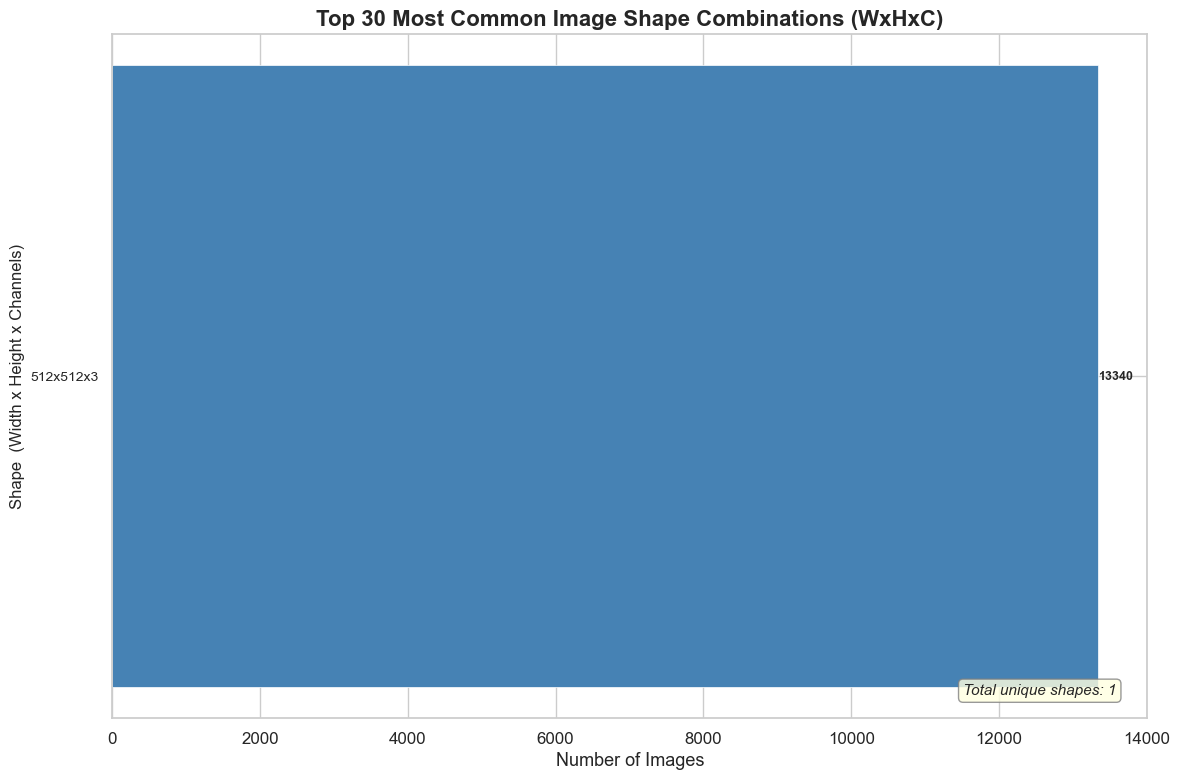


📊  1 unique (W, H, C) combinations found.
     Most common shape: 512x512x3  (13340 images)


In [12]:
# ──────────────────────────────────────────────
# 3b. Bar chart – Image count per (W, H, C) combo
# ──────────────────────────────────────────────

# Create a readable label for each shape combination
df['shape_label'] = df.apply(
    lambda r: f"{r['width']}x{r['height']}x{r['channels']}", axis=1
)

shape_counts = df['shape_label'].value_counts()

# Show top-30 most common combinations (there may be many unique sizes)
top_n = 30
top_shapes = shape_counts.head(top_n).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, max(8, len(top_shapes) * 0.38)))
bars = ax.barh(top_shapes.index, top_shapes.values,
              color='Steelblue', edgecolor='white', linewidth=0.5)

# Annotate each bar
for bar, count in zip(bars, top_shapes.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(count), va='center', fontsize=9, fontweight='bold')

ax.set_title(f'Top {top_n} Most Common Image Shape Combinations (WxHxC)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Images', fontsize=13)
ax.set_ylabel('Shape  (Width x Height x Channels)', fontsize=12)
ax.tick_params(axis='y', labelsize=10)

# Summary text
ax.text(0.97, 0.03,
        f'Total unique shapes: {len(shape_counts)}',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=11, fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray', alpha=0.8))

plt.tight_layout()
plt.savefig('shape_combinations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊  {len(shape_counts)} unique (W, H, C) combinations found.')
print(f'     Most common shape: {shape_counts.index[0]}  ({shape_counts.iloc[0]} images)')


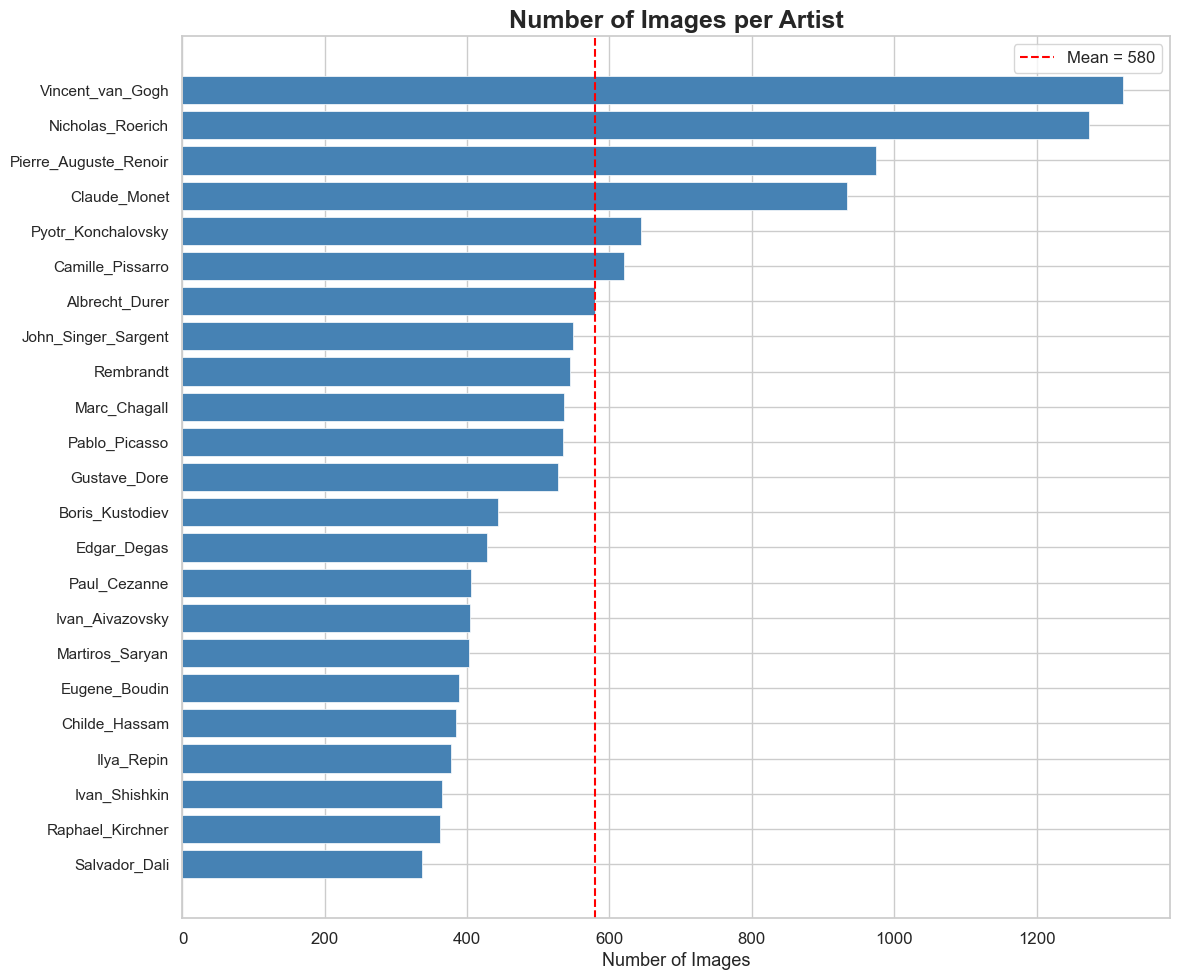

In [13]:
# ──────────────────────────────────────────────
# 4.  Visualization 2 – Images per Artist
# ──────────────────────────────────────────────

artist_counts = df["artist"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(
    artist_counts.index,
    artist_counts.values,
    color='Steelblue',
    edgecolor="white",
    linewidth=0.5,
)

ax.set_title("Number of Images per Artist", fontsize=18, fontweight="bold")
ax.set_xlabel("Number of Images", fontsize=13)
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=11)
# Add mean line
mean_count = artist_counts.mean()
ax.axvline(mean_count, color="red", ls="--", lw=1.5, label=f"Mean = {mean_count:.0f}")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('images_per_artist.png', dpi=150, bbox_inches='tight')
plt.show()



⏳ Computing per-image pixel statistics …


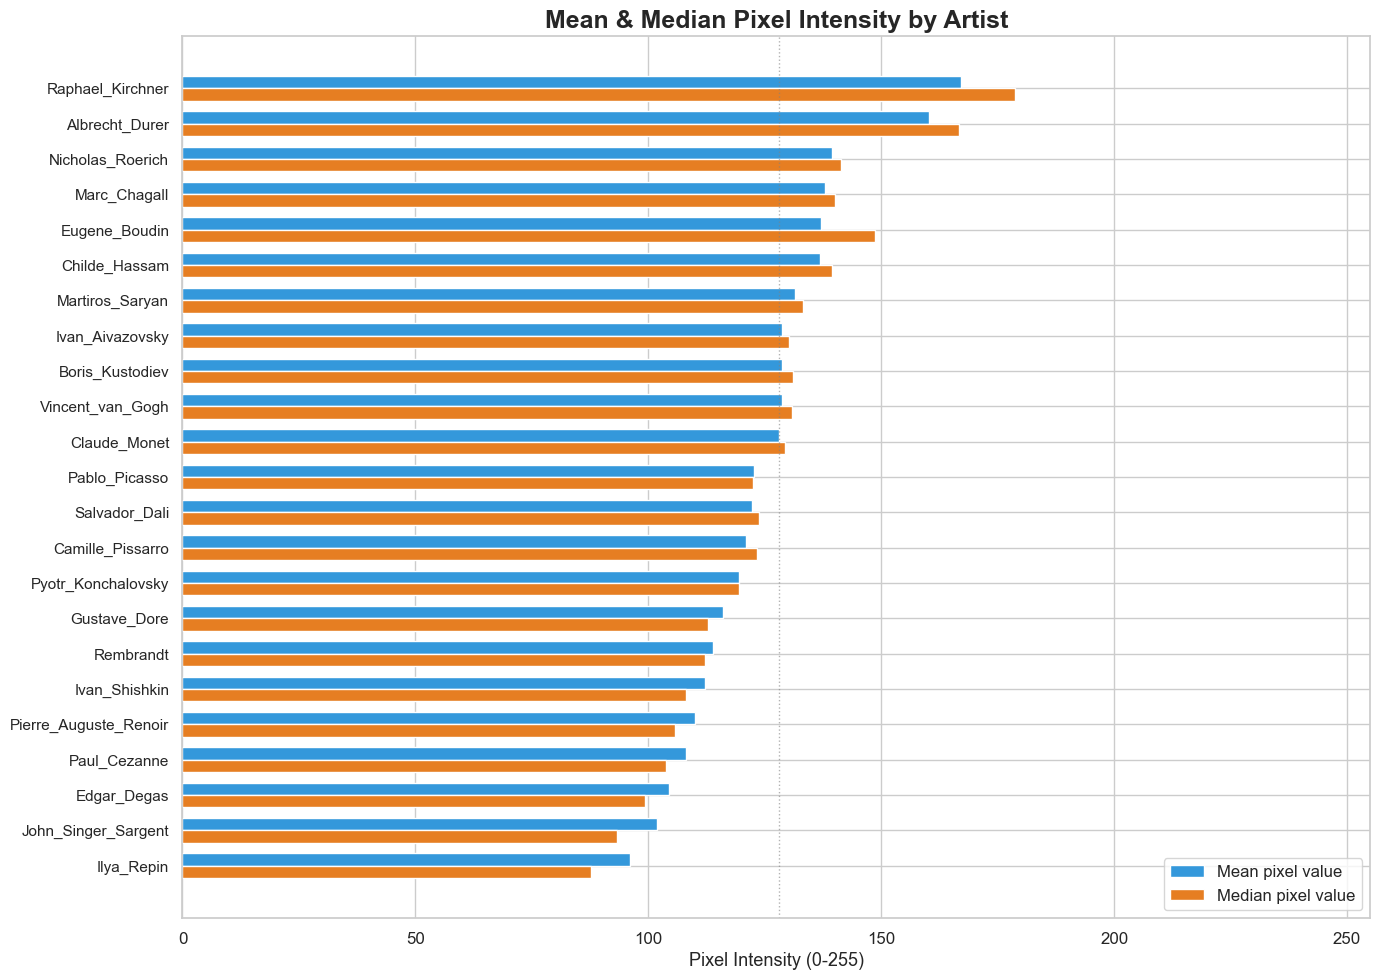

In [14]:
# ──────────────────────────────────────────────
# 5.  Visualization 3 – Mean & Median Pixel
#     Intensity by Artist
# ──────────────────────────────────────────────

print("\n⏳ Computing per-image pixel statistics …")
df["pixel_mean"] = df["image_array"].apply(lambda x: x.mean())
df["pixel_median"] = df["image_array"].apply(lambda x: np.median(x))

# Aggregate per artist
stats = df.groupby("artist").agg(
    mean_pixel=("pixel_mean", "mean"),
    median_pixel=("pixel_median", "mean"),
).sort_values("mean_pixel", ascending=True)

fig, ax = plt.subplots(figsize=(14, 10))
y = np.arange(len(stats))
bar_height = 0.35

bars_mean = ax.barh(y + bar_height / 2, stats["mean_pixel"], bar_height,
                    label="Mean pixel value", color="#3498db", edgecolor="white")
bars_median = ax.barh(y - bar_height / 2, stats["median_pixel"], bar_height,
                      label="Median pixel value", color="#e67e22", edgecolor="white")

ax.set_yticks(y)
ax.set_yticklabels(stats.index, fontsize=11)
ax.set_xlabel("Pixel Intensity (0-255)", fontsize=13)
ax.set_title("Mean & Median Pixel Intensity by Artist", fontsize=18, fontweight="bold")
ax.legend(fontsize=12, loc="lower right")
ax.set_xlim(0, 255)

# Add a subtle vertical reference at 128 (mid-range)
ax.axvline(128, color="gray", ls=":", lw=1, alpha=0.6, label="Mid-range (128)")

plt.tight_layout()
plt.savefig('pixel_intensity_by_artist.png', dpi=150, bbox_inches='tight')
plt.show()



⏳ Computing per-channel (R, G, B) statistics …


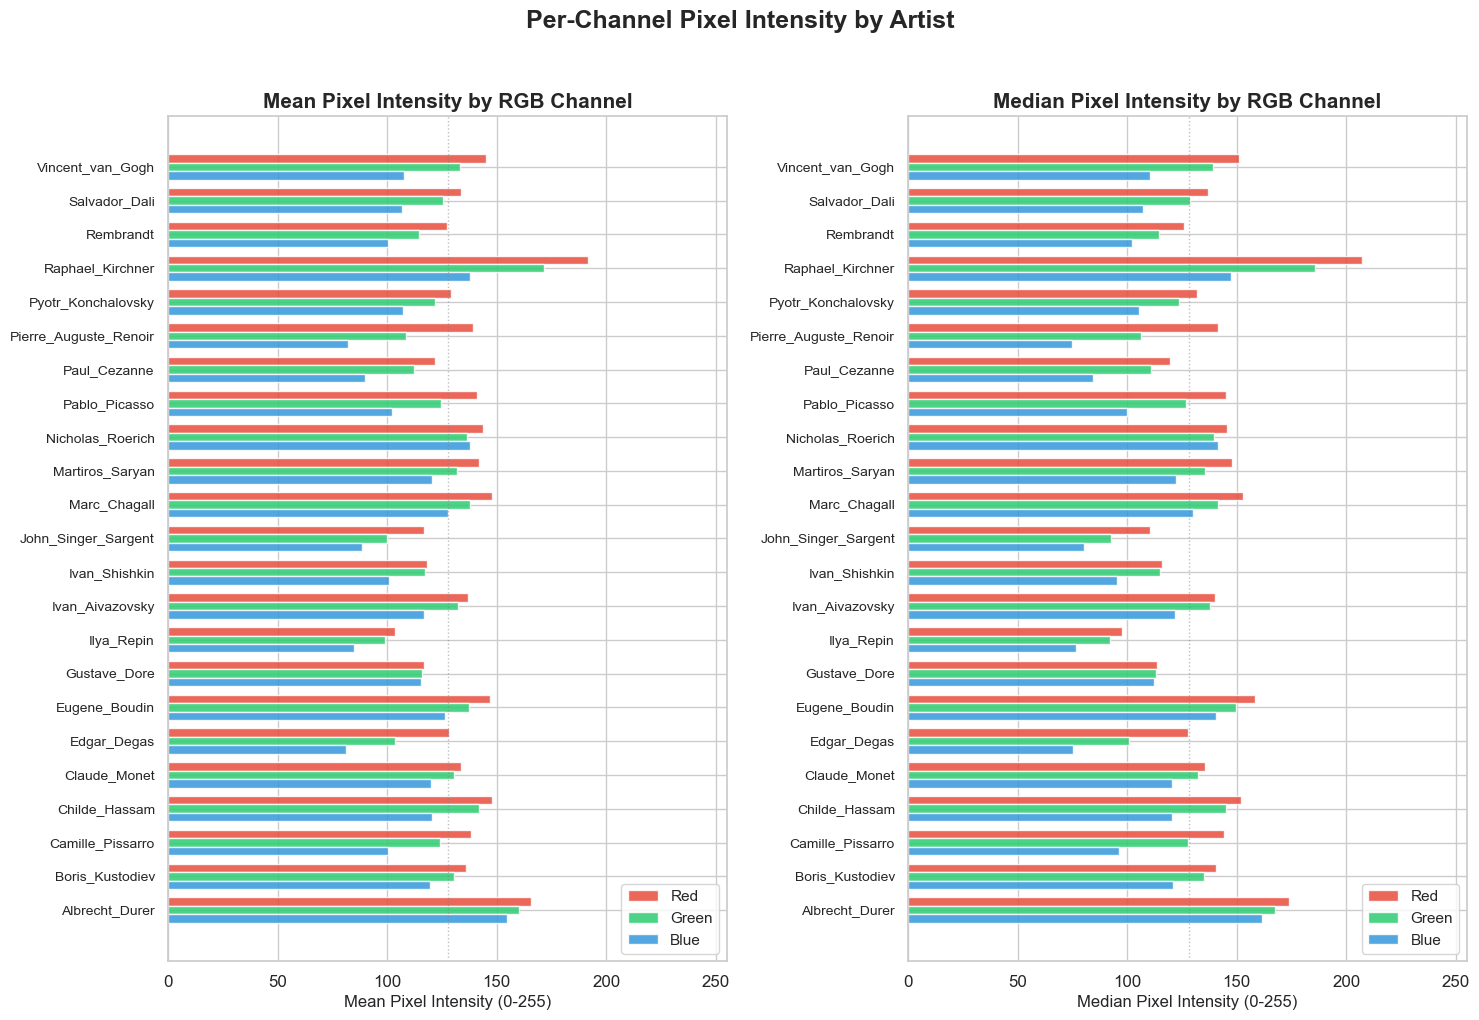


✅ Saved: pixel_intensity_rgb_by_artist.png


In [15]:
# ──────────────────────────────────────────────
# 5b.  Mean & Median Pixel Intensity by RGB
#      Channel per Artist
# ──────────────────────────────────────────────

print("\n⏳ Computing per-channel (R, G, B) statistics …")

# Compute mean and median for each channel per image
df["mean_R"] = df["image_array"].apply(lambda x: x[:, :, 0].mean())
df["mean_G"] = df["image_array"].apply(lambda x: x[:, :, 1].mean())
df["mean_B"] = df["image_array"].apply(lambda x: x[:, :, 2].mean())
df["median_R"] = df["image_array"].apply(lambda x: np.median(x[:, :, 0]))
df["median_G"] = df["image_array"].apply(lambda x: np.median(x[:, :, 1]))
df["median_B"] = df["image_array"].apply(lambda x: np.median(x[:, :, 2]))

# Aggregate per artist
rgb_stats = df.groupby("artist").agg(
    mean_R=("mean_R", "mean"),
    mean_G=("mean_G", "mean"),
    mean_B=("mean_B", "mean"),
    median_R=("median_R", "mean"),
    median_G=("median_G", "mean"),
    median_B=("median_B", "mean"),
).sort_index()

# ── Plot 1: Mean pixel intensity per channel ──
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

artists = rgb_stats.index
y_pos = np.arange(len(artists))
bar_h = 0.25

# -- Left panel: MEAN --
ax = axes[0]
ax.barh(y_pos + bar_h, rgb_stats["mean_R"], bar_h,
        label="Red",   color="#e74c3c", edgecolor="white", alpha=0.85)
ax.barh(y_pos,         rgb_stats["mean_G"], bar_h,
        label="Green", color="#2ecc71", edgecolor="white", alpha=0.85)
ax.barh(y_pos - bar_h, rgb_stats["mean_B"], bar_h,
        label="Blue",  color="#3498db", edgecolor="white", alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(artists, fontsize=10)
ax.set_xlabel("Mean Pixel Intensity (0-255)", fontsize=12)
ax.set_title("Mean Pixel Intensity by RGB Channel",
             fontsize=15, fontweight="bold")
ax.set_xlim(0, 255)
ax.axvline(128, color="gray", ls=":", lw=1, alpha=0.5)
ax.legend(fontsize=11, loc="lower right")

# -- Right panel: MEDIAN --
ax = axes[1]
ax.barh(y_pos + bar_h, rgb_stats["median_R"], bar_h,
        label="Red",   color="#e74c3c", edgecolor="white", alpha=0.85)
ax.barh(y_pos,         rgb_stats["median_G"], bar_h,
        label="Green", color="#2ecc71", edgecolor="white", alpha=0.85)
ax.barh(y_pos - bar_h, rgb_stats["median_B"], bar_h,
        label="Blue",  color="#3498db", edgecolor="white", alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(artists, fontsize=10)
ax.set_xlabel("Median Pixel Intensity (0-255)", fontsize=12)
ax.set_title("Median Pixel Intensity by RGB Channel",
             fontsize=15, fontweight="bold")
ax.set_xlim(0, 255)
ax.axvline(128, color="gray", ls=":", lw=1, alpha=0.5)
ax.legend(fontsize=11, loc="lower right")

plt.suptitle("Per-Channel Pixel Intensity by Artist",
             fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig('pixel_intensity_rgb_by_artist.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved: pixel_intensity_rgb_by_artist.png")


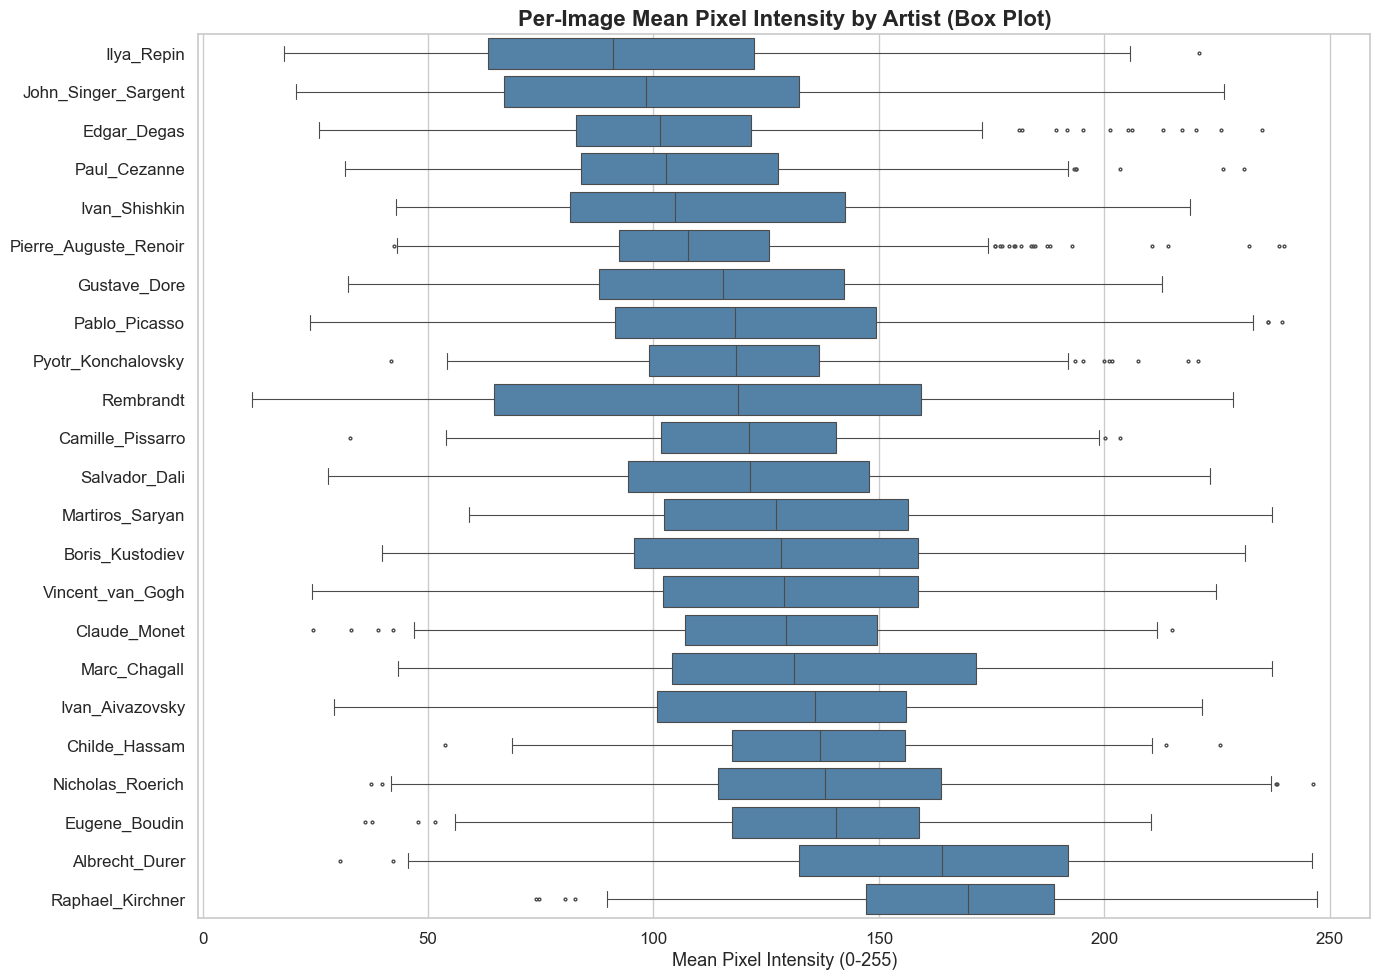

In [16]:
# ──────────────────────────────────────────────
# 6.  Box-plot view of per-image means
# ──────────────────────────────────────────────

order = df.groupby("artist")["pixel_mean"].median().sort_values().index

fig, ax = plt.subplots(figsize=(14, 10))
sns.boxplot(
    data=df, y="artist", x="pixel_mean",
    order=order, color="steelblue", ax=ax,
    fliersize=2, linewidth=0.8,
)
ax.set_title("Per-Image Mean Pixel Intensity by Artist (Box Plot)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Mean Pixel Intensity (0-255)", fontsize=13)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig('pixel_intensity_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


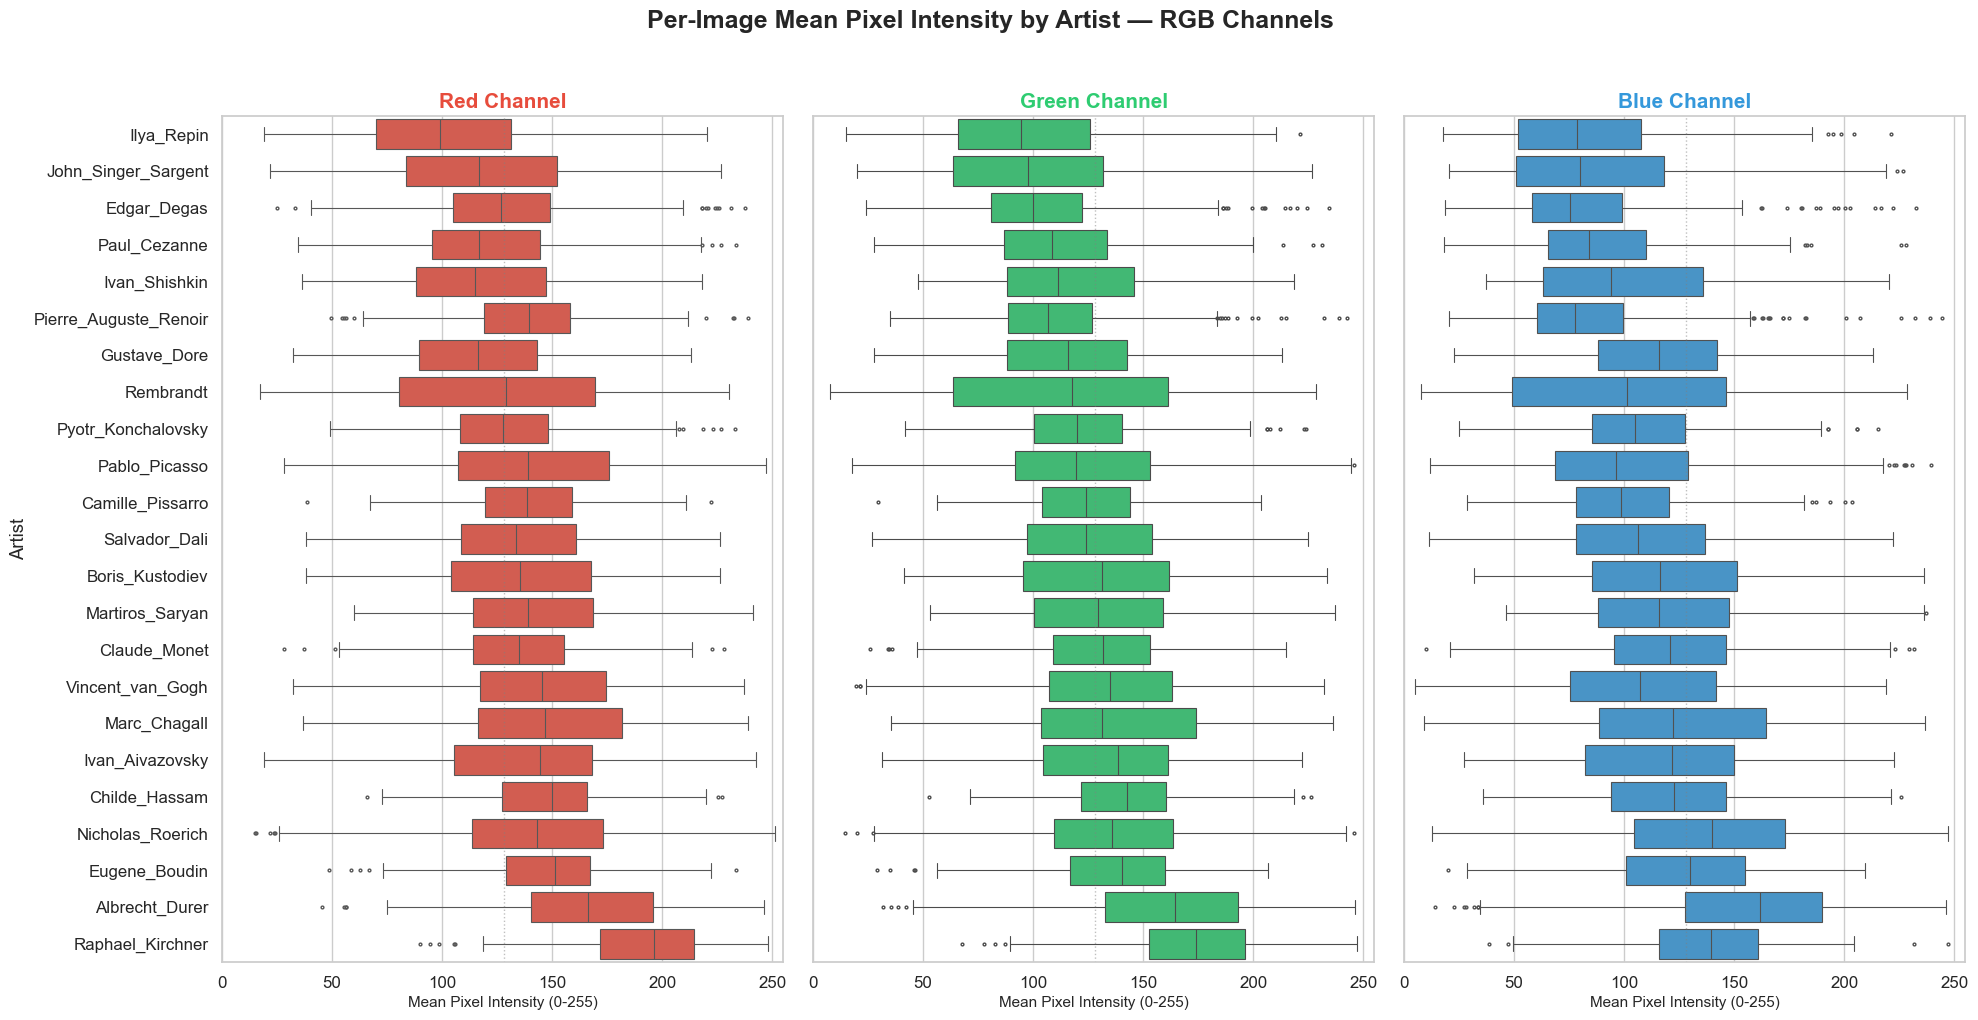


✅ Saved: pixel_intensity_boxplot_rgb.png


In [18]:
# ──────────────────────────────────────────────
# 6b.  Box-plot of per-image mean by RGB channel
#      per Artist
# ──────────────────────────────────────────────

# Reshape data into long format so each row is (artist, channel, value)
df_rgb_long = df[["artist", "mean_R", "mean_G", "mean_B"]].melt(
    id_vars="artist",
    value_vars=["mean_R", "mean_G", "mean_B"],
    var_name="channel",
    value_name="mean_intensity",
)
# Pretty channel labels
df_rgb_long["channel"] = df_rgb_long["channel"].map(
    {"mean_R": "Red", "mean_G": "Green", "mean_B": "Blue"}
)

# Sort artists by overall mean across channels
order_rgb = (
    df_rgb_long.groupby("artist")["mean_intensity"]
    .median()
    .sort_values()
    .index
)

# One subplot per channel, stacked vertically
channel_info = [
    ("Red",   "#e74c3c", "Reds"),
    ("Green", "#2ecc71", "Greens"),
    ("Blue",  "#3498db", "Blues"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)

for ax, (ch_name, ch_color, ch_palette) in zip(axes, channel_info):
    subset = df_rgb_long[df_rgb_long["channel"] == ch_name]
    sns.boxplot(
        data=subset, y="artist", x="mean_intensity",
        order=order_rgb, color=ch_color, ax=ax,
        fliersize=2, linewidth=0.8, saturation=0.75,
    )
    ax.set_title(f"{ch_name} Channel", fontsize=15, fontweight="bold",
                 color=ch_color)
    ax.set_xlabel("Mean Pixel Intensity (0-255)", fontsize=11)
    ax.set_ylabel("" if ax != axes[0] else "Artist")
    ax.set_xlim(0, 255)
    ax.axvline(128, color="gray", ls=":", lw=1, alpha=0.5)

plt.suptitle("Per-Image Mean Pixel Intensity by Artist — RGB Channels",
             fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig('pixel_intensity_boxplot_rgb.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved: pixel_intensity_boxplot_rgb.png")


In [31]:
import plotly.express as px

# 2. Build the interactive 3D scatter plot
fig = px.scatter_3d(
    df, 
    x='mean_R', 
    y='mean_G', 
    z='mean_B',
    color='artist',
    title='3D Graph of Images by Mean RGB Values',
    labels={
        'mean_R': 'Mean Red',
        'mean_G': 'Mean Green',
        'mean_B': 'Mean Blue'
    },
    opacity=0.5
)

# Make the dots slightly smaller for better visibility with 13k+ points
fig.update_traces(marker=dict(size=2))

# Display the plot
fig.show()